# APPROCHE 1 : CHAIN LADDER (METHODE ACTUARIELLE CLASSIQUE)

## Introduction

La methode Chain Ladder est une technique actuarielle traditionnelle utilisee pour projeter les montants futurs a partir de donnees historiques triangulaires. Initialement developpee pour le provisionnement des sinistres en assurance, elle est adaptee ici pour modeliser l'evolution des remboursements anticipes.

## Principe theorique

### 1.1 Triangle de developpement (Run-off triangle)

Un triangle de developpement est une matrice ou :
- **Lignes** = Cohortes (groupes de contrats par date d'origination)
- **Colonnes** = Maturite developpee (age depuis origination)
- **Valeurs** = Montant ou taux observe (ici : ER moyen)

Structure d'un triangle :

```
Cohorte      Age 1   Age 2   Age 3   Age 4   ...
2019-01      0.25    0.30    0.35    0.40
2019-02      0.28    0.32    0.38    ?
2019-03      0.26    0.31    ?       ?
2019-04      0.29    ?       ?       ?
```

La partie superieure droite est **incomplete** (triangulaire) car les cohortes recentes n'ont pas encore atteint les maturites elevees.

### 1.2 Facteurs de developpement (Link Ratios)

Les facteurs de developpement mesurent la croissance d'une colonne a l'autre :

$$f_j = \frac{\sum_{i} C_{i,j+1}}{\sum_{i} C_{i,j}}$$

ou :
- $C_{i,j}$ = valeur cumulee pour la cohorte i a la maturite j
- $f_j$ = facteur de passage de l'age j a l'age j+1

**Interpretation** : Si $f_3 = 1.15$, cela signifie qu'en moyenne, la valeur augmente de 15% entre l'age 3 et l'age 4.

### 1.3 Projection des valeurs futures

Pour completer le triangle, on applique les facteurs aux valeurs observees :

$$C_{i,j+1} = C_{i,j} \times f_j$$

On repete l'operation jusqu'a la maturite finale.

### 1.4 Obtention de la baseline

La courbe ER_baseline(age) est obtenue en moyennant les valeurs projetees de toutes les cohortes :

$$ER\_baseline(j) = \frac{1}{n} \sum_{i=1}^{n} C_{i,j}$$

## Application au remboursement anticipe

Dans notre contexte :
- **Cohortes** = contrats groupes par mois d'origination
- **Maturite** = age du pret en mois
- **Valeur** = ER moyen observe (RA/Encours)

L'objectif est d'obtenir une courbe representative de l'evolution "naturelle" de l'ER selon l'age du pret, independamment des caracteristiques individuelles.

## Imports et configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


Bibliotheques chargees avec succes


## Etape 1 : Chargement et preparation des donnees

In [2]:
# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset charge : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Nettoyage de base
cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Conversion date
df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

# EAD
if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

# Variables categorielles
for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

# Imputation
df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

# Age du pret
df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

print("Preparation terminee")

Dataset charge : 100000 lignes, 20 colonnes
Preparation terminee


## Etape 2 : Calcul de l'encours et de l'ER

### Formule de l'encours

L'encours represente le capital restant du AVANT remboursement anticipe :

$$Encours = Capital\_emprunt - Montant\_rembourse$$

ou :
- $Capital\_emprunt$ = capital initial emprunte (calcule via formule d'annuites)
- $Montant\_rembourse$ = capital deja rembourse = $(B\_MAT - B\_RESMAT) \times MTECH$

### Formule du capital emprunte (annuites)

Pour un pret a mensualites constantes :

$$Capital\_emprunt = MTECH \times \frac{1 - (1 + \frac{Tx}{1200})^{-N}}{\frac{Tx}{1200}}$$

ou :
- $MTECH$ = mensualite
- $Tx$ = taux annuel en pourcentage
- $N$ = nombre total d'echeances

### Formule de l'ER (taux de remboursement anticipe)

$$ER = \frac{RA}{Encours}$$

avec clippage entre 0 et 1.

In [3]:
# Calcul capital emprunte
df["Capital_emprunt"] = df["MTECH"] * (
    (1 - (1 + (df["Tx"] / 1200)) ** (-df["NB_ECH"])) / (df["Tx"] / 1200)
)

# Calcul montant rembourse
df["Montant_rembourse"] = (
    (df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"].clip(lower=0)
).round(2)

# Calcul encours
df["Encours"] = (df["Capital_emprunt"] - df["Montant_rembourse"]).clip(lower=1)

# Calcul ER
df["ER_obs"] = (df["RA"] / df["Encours"]).clip(lower=0, upper=1)
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

# Filtrage
df = df[(df["ER_obs"] <= 1) & (df["Encours"] > 0)]

# Creation cohorte
df["Date_origination"] = df["DARRET"] - pd.to_timedelta(df["AGE_PRET"] * 30, unit='D')
df["Cohorte"] = df["Date_origination"].dt.to_period('M')

print(f"Donnees preparees : {len(df)} contrats")
print(f"ER_obs moyen : {df['ER_obs'].mean():.4f}")
print(f"FLAG_ER (taux RA) : {df['FLAG_ER'].mean():.2%}")
print(f"Nombre de cohortes : {df['Cohorte'].nunique()}")
print(f"Periode : {df['Cohorte'].min()} a {df['Cohorte'].max()}")

Donnees preparees : 26519 contrats
ER_obs moyen : 0.7819
FLAG_ER (taux RA) : 97.10%
Nombre de cohortes : 302
Periode : 1994-06 a 2023-12


## Etape 3 : Construction du triangle de developpement

### Filtre de robustesse

Pour garantir la stabilite des estimations, nous :
1. Limitons aux **5 dernieres annees** de cohortes (comportements recents)
2. Excluons les cellules avec **moins de 5 observations** (variance trop elevee)

In [4]:
# Filtrer cohortes recentes (5 ans = 60 mois)
date_cutoff = df['Cohorte'].max() - 60
df_recent = df[df['Cohorte'] >= date_cutoff].copy()

print(f"Donnees filtrees : {len(df_recent)} contrats")
print(f"Periode cohortes : {df_recent['Cohorte'].min()} a {df_recent['Cohorte'].max()}")

# Construction triangle ER
triangle_er = df_recent.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='mean'
)

# Triangle volume (nombre d'observations)
triangle_volume = df_recent.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='count'
)

# Appliquer filtre : remplacer par NaN si < 5 observations
triangle_er_filtered = triangle_er.copy()
triangle_er_filtered[triangle_volume < 5] = np.nan

print(f"\nDimensions triangle : {triangle_er_filtered.shape}")
print(f"Taux de remplissage : {(~triangle_er_filtered.isna()).sum().sum() / triangle_er_filtered.size:.1%}")
print(f"\nTriangle ER (extrait 5 premieres cohortes x 10 premiers ages) :")
print(triangle_er_filtered.iloc[:5, :10])

Donnees filtrees : 8634 contrats
Periode cohortes : 2018-12 a 2023-12

Dimensions triangle : (61, 61)
Taux de remplissage : 22.2%

Triangle ER (extrait 5 premieres cohortes x 10 premiers ages) :
AGE_PRET  0.0       1.0       2.0       3.0       4.0       5.0       6.0  \
Cohorte                                                                     
2018-12   NaN       NaN  0.538191  0.493111       NaN  0.456016       NaN   
2019-01   NaN  0.512614       NaN  0.555912       NaN       NaN  0.331248   
2019-02   NaN       NaN       NaN       NaN  0.250556       NaN  0.592972   
2019-03   NaN       NaN  0.671694  0.692226  0.630599       NaN       NaN   
2019-04   NaN       NaN       NaN  0.560806  0.503314  0.452008  0.400246   

AGE_PRET       7.0       8.0       9.0  
Cohorte                                 
2018-12   0.504333  0.392440  0.562042  
2019-01   0.256564  0.603388  0.705605  
2019-02   0.614547  0.594628  0.656133  
2019-03   0.902060  0.721600       NaN  
2019-04   0.591422 

### Visualisation du triangle

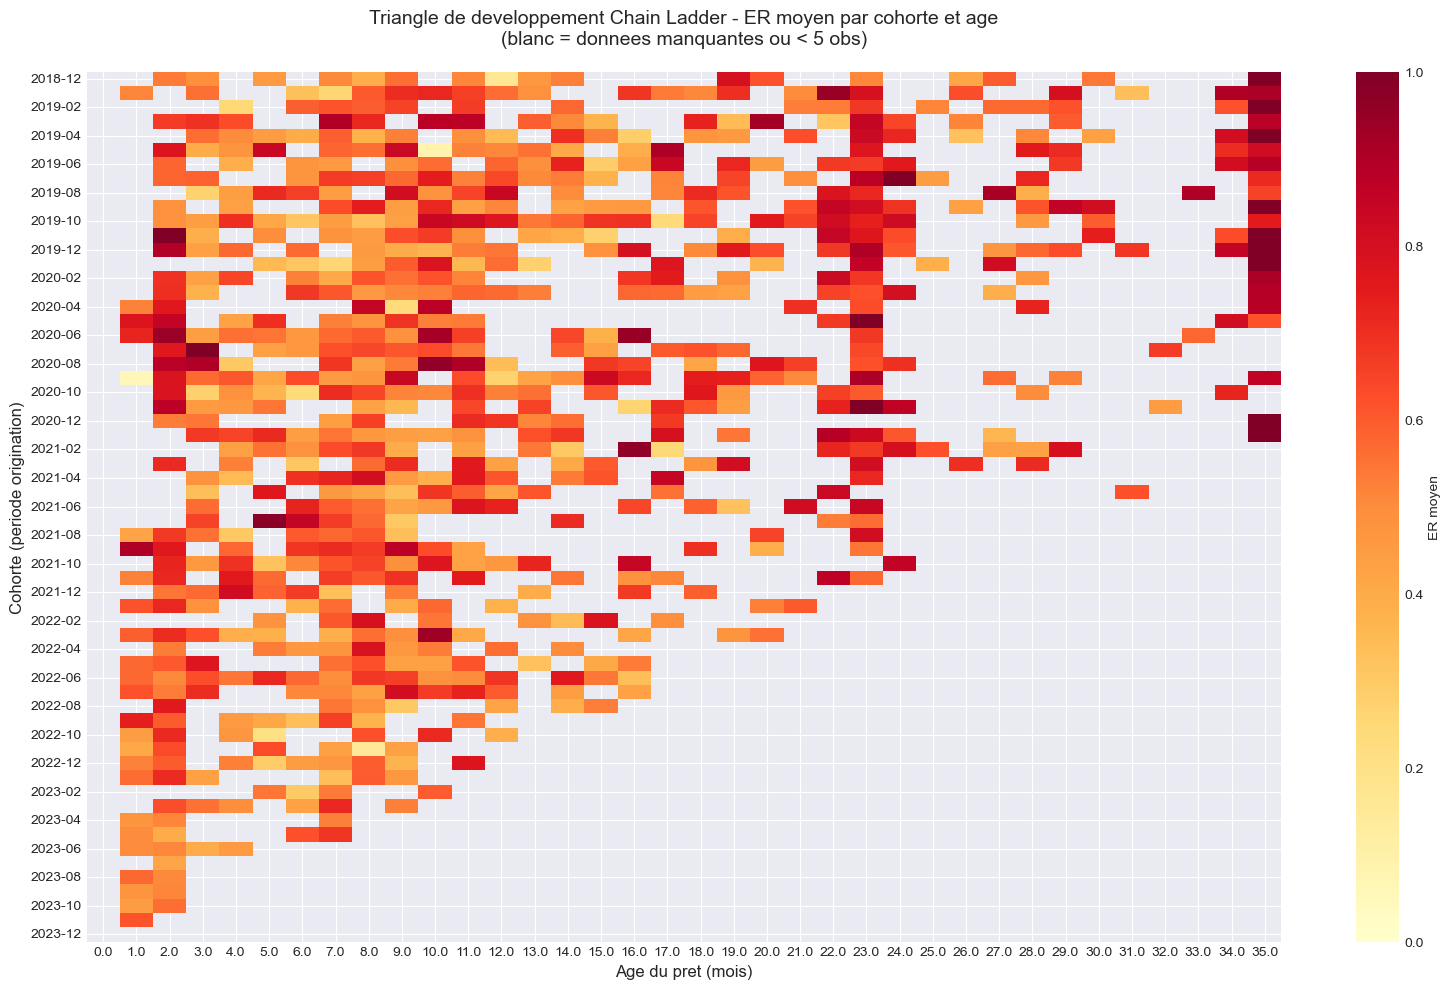

Interpretation :
  - Les cases en blanc representent les donnees manquantes (triangle incomplet)
  - Les couleurs chaudes (rouge/orange) indiquent un ER eleve
  - On observe la structure triangulaire typique de Chain Ladder


In [5]:
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(triangle_er_filtered.iloc[:, :36], annot=False, cmap='YlOrRd', 
            cbar_kws={'label': 'ER moyen'}, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Age du pret (mois)', fontsize=12)
ax.set_ylabel('Cohorte (periode origination)', fontsize=12)
ax.set_title('Triangle de developpement Chain Ladder - ER moyen par cohorte et age\n(blanc = donnees manquantes ou < 5 obs)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Les cases en blanc representent les donnees manquantes (triangle incomplet)")
print("  - Les couleurs chaudes (rouge/orange) indiquent un ER eleve")
print("  - On observe la structure triangulaire typique de Chain Ladder")

## Etape 4 : Calcul des facteurs de developpement

### Methode robuste

Pour chaque age j, le facteur $f_j$ est calcule comme la moyenne ponderee des ratios individuels :

$$f_j = \frac{\sum_{i \in I_j} w_i \cdot r_i}{\sum_{i \in I_j} w_i}$$

ou :
- $r_i = \frac{ER(i,j+1)}{ER(i,j)}$ = ratio de developpement pour la cohorte i
- $w_i = ER(i,j)$ = poids (valeur a l'age j)
- $I_j$ = ensemble des cohortes avec donnees valides aux ages j et j+1

### Filtres de robustesse

1. **Minimum 3 cohortes** avec donnees valides
2. **Ratios aberrants exclus** : on garde uniquement $0.5 \leq r_i \leq 2.0$
3. **Facteur = 1.0 par defaut** si criteres non respectes

In [6]:
def calculate_development_factors(triangle, min_cohortes=3):
    """
    Calcule les facteurs de developpement Chain Ladder avec filtres de robustesse.
    
    Parameters:
    -----------
    triangle : DataFrame
        Triangle de developpement filtre
    min_cohortes : int
        Nombre minimum de cohortes requises pour calculer un facteur
    
    Returns:
    --------
    dict : {age: facteur}
    """
    factors = {}
    
    for j in range(len(triangle.columns) - 1):
        col_current = triangle.columns[j]
        col_next = triangle.columns[j + 1]
        
        # Cohortes avec donnees valides aux deux ages
        mask = (triangle[col_current] > 0) & (triangle[col_next].notna())
        
        if mask.sum() >= min_cohortes:
            # Calcul des ratios
            ratios = triangle.loc[mask, col_next] / triangle.loc[mask, col_current]
            weights = triangle.loc[mask, col_current]
            
            # Filtrer ratios aberrants
            mask_valid = (ratios >= 0.5) & (ratios <= 2.0)
            
            if mask_valid.sum() >= min_cohortes:
                # Moyenne ponderee
                factor = np.average(ratios[mask_valid], weights=weights[mask_valid])
            else:
                factor = 1.0
            
            factors[col_current] = factor
        else:
            factors[col_current] = 1.0
    
    return factors

# Calcul des facteurs
factors_er = calculate_development_factors(triangle_er_filtered, min_cohortes=3)

print("FACTEURS DE DEVELOPPEMENT CHAIN LADDER")
print("=" * 60)
print(f"{'Age':<10} {'Facteur':<15} {'Interpretation'}")
print("-" * 60)

for age, factor in sorted(factors_er.items())[:20]:
    if factor > 1.05:
        interp = "Croissance forte"
    elif factor > 1.01:
        interp = "Croissance moderee"
    elif factor > 0.99:
        interp = "Stable"
    elif factor > 0.95:
        interp = "Decroissance moderee"
    else:
        interp = "Decroissance forte"
    
    print(f"{age:<10.0f} {factor:<15.4f} {interp}")

print("...")
print(f"\nTotal facteurs calcules : {len(factors_er)}")

FACTEURS DE DEVELOPPEMENT CHAIN LADDER
Age        Facteur         Interpretation
------------------------------------------------------------
0          1.0000          Stable
1          1.1228          Croissance forte
2          0.8638          Decroissance forte
3          1.0901          Croissance forte
4          0.9974          Stable
5          0.9163          Decroissance forte
6          1.0795          Croissance forte
7          1.0129          Croissance moderee
8          0.9618          Decroissance moderee
9          1.1311          Croissance forte
10         0.9785          Decroissance moderee
11         0.9565          Decroissance moderee
12         0.9888          Decroissance moderee
13         0.9863          Decroissance moderee
14         0.9516          Decroissance moderee
15         1.0034          Stable
16         1.1220          Croissance forte
17         0.9869          Decroissance moderee
18         0.9769          Decroissance moderee
19         0.8

### Visualisation des facteurs

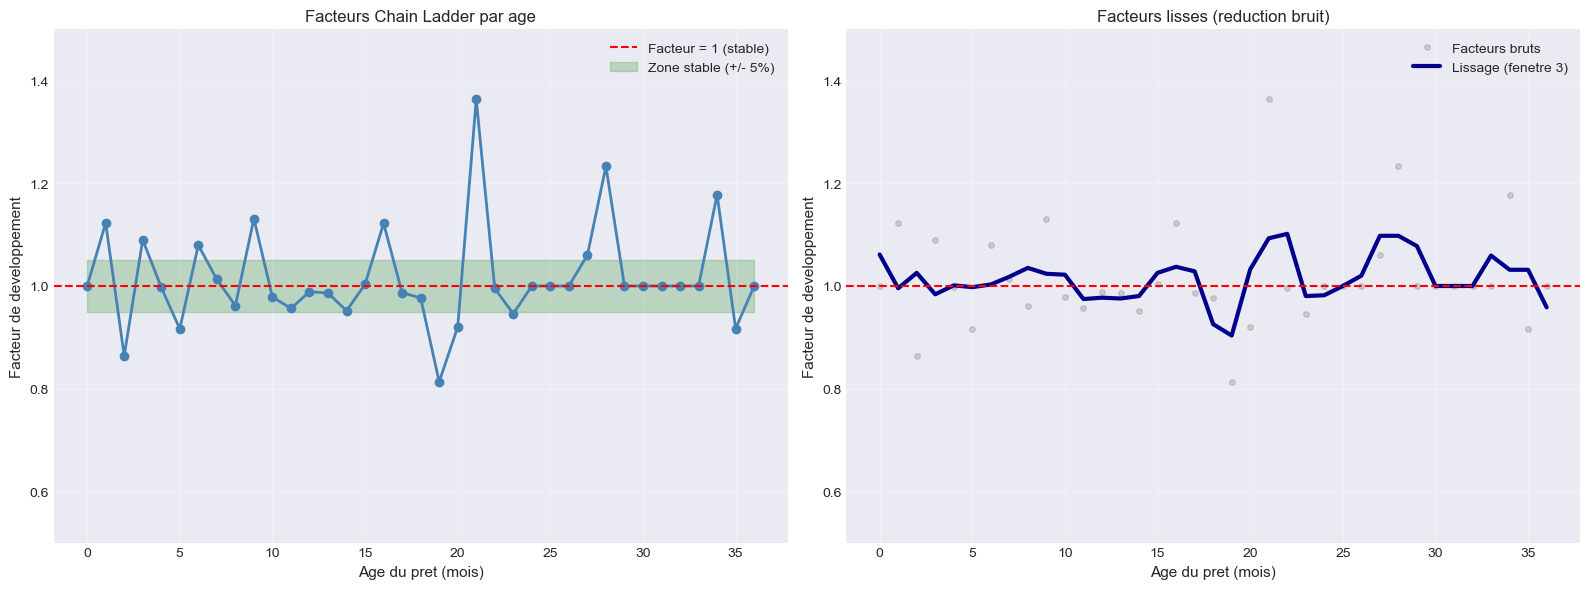

Interpretation :
  - Facteur > 1 : l'ER augmente avec l'age
  - Facteur < 1 : l'ER diminue avec l'age
  - Facteur = 1 : l'ER reste stable
  - La variabilite indique la volatilite des comportements entre cohortes


In [7]:
ages = sorted([k for k in factors_er.keys() if k <= 36])
values = [factors_er[age] for age in ages]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Graphique 1 : Facteurs bruts
axes[0].plot(ages, values, 'o-', linewidth=2, markersize=6, color='steelblue')
axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Facteur = 1 (stable)')
axes[0].fill_between(ages, 0.95, 1.05, alpha=0.2, color='green', label='Zone stable (+/- 5%)')
axes[0].set_xlabel('Age du pret (mois)', fontsize=11)
axes[0].set_ylabel('Facteur de developpement', fontsize=11)
axes[0].set_title('Facteurs Chain Ladder par age', fontsize=12)
axes[0].set_ylim(0.5, 1.5)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Lissage (moyenne mobile)
window = 3
values_smooth = pd.Series(values).rolling(window=window, center=True, min_periods=1).mean()
axes[1].plot(ages, values, 'o', alpha=0.3, markersize=4, color='gray', label='Facteurs bruts')
axes[1].plot(ages, values_smooth, '-', linewidth=3, color='darkblue', label=f'Lissage (fenetre {window})')
axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Age du pret (mois)', fontsize=11)
axes[1].set_ylabel('Facteur de developpement', fontsize=11)
axes[1].set_title('Facteurs lisses (reduction bruit)', fontsize=12)
axes[1].set_ylim(0.5, 1.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Facteur > 1 : l'ER augmente avec l'age")
print("  - Facteur < 1 : l'ER diminue avec l'age")
print("  - Facteur = 1 : l'ER reste stable")
print("  - La variabilite indique la volatilite des comportements entre cohortes")

## Etape 5 : Projection du triangle

On applique les facteurs pour completer le triangle :

$$ER_{projected}(i, j+1) = ER_{observed}(i, j) \times f_j$$

On repete jusqu'a la maturite maximale (60 mois ici).

In [8]:
def project_triangle(triangle, factors, max_age=60):
    """
    Projette un triangle en appliquant les facteurs de developpement.
    """
    triangle_proj = triangle.copy()
    
    for cohorte in triangle_proj.index:
        # Derniere valeur observee pour cette cohorte
        last_obs = triangle_proj.loc[cohorte].last_valid_index()
        
        if last_obs is not None and last_obs < max_age:
            current_val = triangle_proj.loc[cohorte, last_obs]
            
            # Projection vers l'avenir
            for age in range(int(last_obs) + 1, min(max_age + 1, len(triangle_proj.columns))):
                if age - 1 in factors:
                    current_val = current_val * factors[age - 1]
                    if age in triangle_proj.columns:
                        triangle_proj.loc[cohorte, age] = current_val
    
    return triangle_proj

# Projection
triangle_er_projected = project_triangle(triangle_er_filtered, factors_er, max_age=60)

print("Triangle projete (extrait 5x15) :")
print(triangle_er_projected.iloc[:5, :15])
print(f"\nTaux de remplissage apres projection : {(~triangle_er_projected.isna()).sum().sum() / triangle_er_projected.size:.1%}")

Triangle projete (extrait 5x15) :
AGE_PRET  0.0       1.0       2.0       3.0       4.0       5.0       6.0   \
Cohorte                                                                      
2018-12    NaN       NaN  0.538191  0.493111       NaN  0.456016       NaN   
2019-01    NaN  0.512614       NaN  0.555912       NaN       NaN  0.331248   
2019-02    NaN       NaN       NaN       NaN  0.250556       NaN  0.592972   
2019-03    NaN       NaN  0.671694  0.692226  0.630599       NaN       NaN   
2019-04    NaN       NaN       NaN  0.560806  0.503314  0.452008  0.400246   

AGE_PRET      7.0       8.0       9.0       10.0      11.0      12.0  \
Cohorte                                                                
2018-12   0.504333  0.392440  0.562042       NaN  0.514269  0.161705   
2019-01   0.256564  0.603388  0.705605  0.720890  0.656478  0.563831   
2019-02   0.614547  0.594628  0.656133       NaN  0.668340       NaN   
2019-03   0.902060  0.721600       NaN  0.875432  0.872765 

### Comparaison triangle observe vs projete

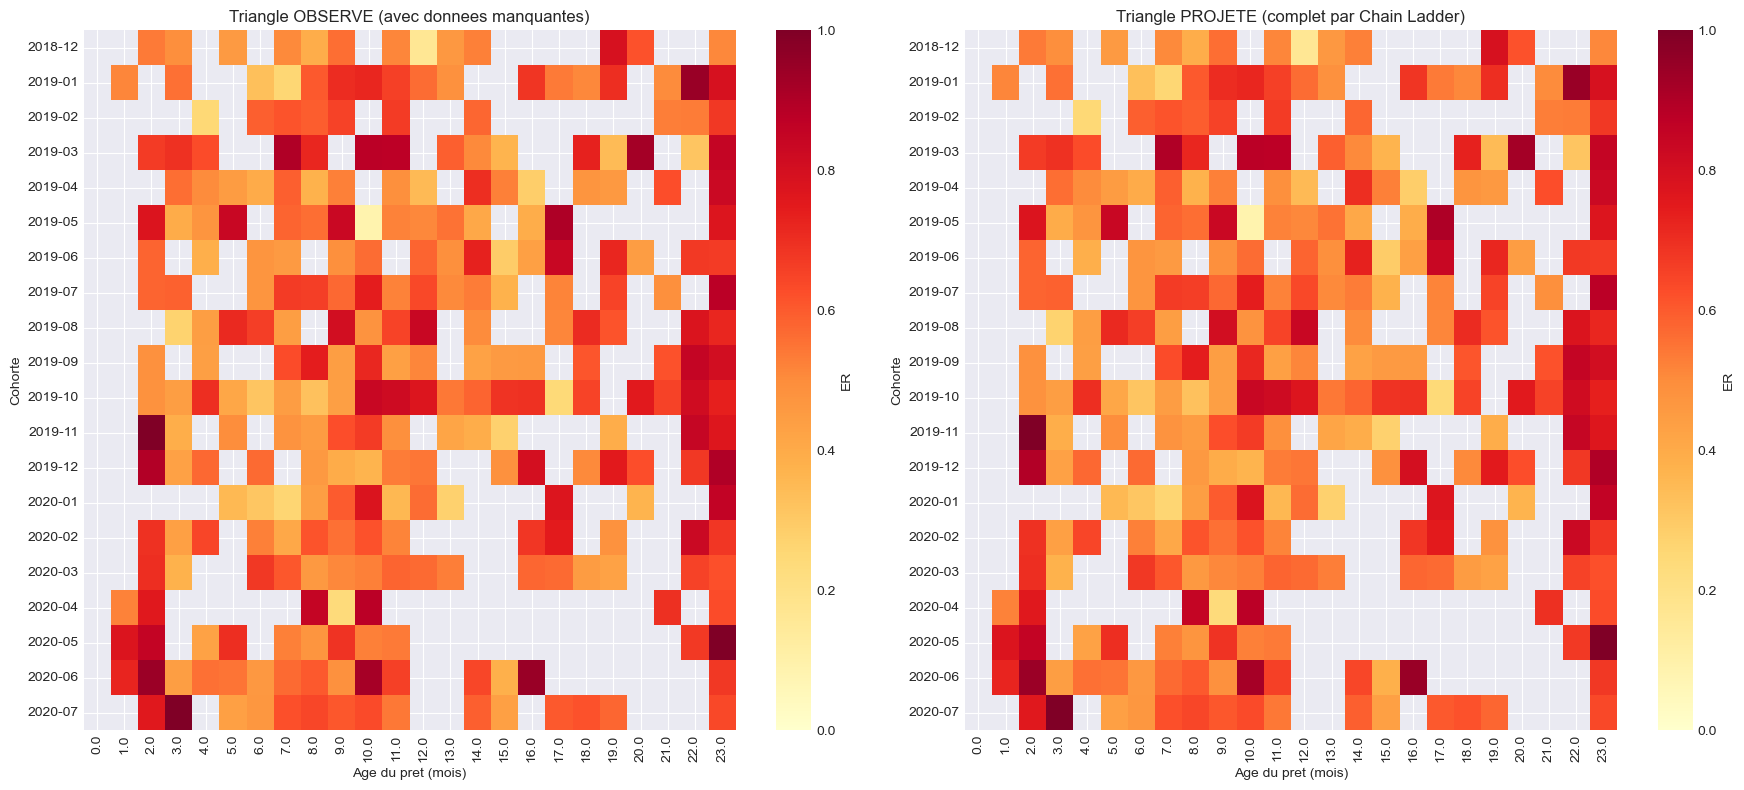

Interpretation :
  - Gauche : triangle original avec zones blanches (donnees manquantes)
  - Droite : triangle complete par projection Chain Ladder
  - Les projections utilisent les patterns historiques des cohortes anterieures


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Triangle observe
sns.heatmap(triangle_er_filtered.iloc[:20, :24], annot=False, cmap='YlOrRd', 
            cbar_kws={'label': 'ER'}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_xlabel('Age du pret (mois)')
axes[0].set_ylabel('Cohorte')
axes[0].set_title('Triangle OBSERVE (avec donnees manquantes)')

# Triangle projete
sns.heatmap(triangle_er_projected.iloc[:20, :24], annot=False, cmap='YlOrRd', 
            cbar_kws={'label': 'ER'}, ax=axes[1], vmin=0, vmax=1)
axes[1].set_xlabel('Age du pret (mois)')
axes[1].set_ylabel('Cohorte')
axes[1].set_title('Triangle PROJETE (complet par Chain Ladder)')

plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - Gauche : triangle original avec zones blanches (donnees manquantes)")
print("  - Droite : triangle complete par projection Chain Ladder")
print("  - Les projections utilisent les patterns historiques des cohortes anterieures")

## Etape 6 : Calcul de la courbe ER_baseline

La courbe ER_baseline(age) est la moyenne de toutes les cohortes (observees + projetees) :

$$ER\_baseline(j) = \frac{1}{n} \sum_{i=1}^{n} ER_{projected}(i, j)$$

### Normalisation

Pour garantir la coherence avec les donnees observees, on normalise :

$$ER\_baseline\_normalized = ER\_baseline \times \frac{\overline{ER_{obs}}}{\overline{ER_{baseline}}}$$

Cela assure que la moyenne de la baseline est egale a la moyenne observee.

In [10]:
# Calculer baseline moyenne
er_baseline_by_age = triangle_er_projected.mean(axis=0, skipna=True)

# Normalisation
er_obs_mean = df['ER_obs'].mean()
er_baseline_mean = er_baseline_by_age.mean()

if er_baseline_mean > 0:
    correction_factor = er_obs_mean / er_baseline_mean
    er_baseline_by_age_normalized = er_baseline_by_age * correction_factor
else:
    er_baseline_by_age_normalized = er_baseline_by_age
    correction_factor = 1.0

print(f"NORMALISATION DE LA BASELINE")
print("=" * 60)
print(f"ER_obs moyen (donnees reelles)     : {er_obs_mean:.4f}")
print(f"ER_baseline moyen (avant correct.) : {er_baseline_mean:.4f}")
print(f"Facteur de correction applique     : {correction_factor:.4f}")
print(f"ER_baseline moyen (apres correct.) : {er_baseline_by_age_normalized.mean():.4f}")
print()
print("ER baseline par age (extrait 20 premiers mois) :")
print(er_baseline_by_age_normalized.head(20))

NORMALISATION DE LA BASELINE
ER_obs moyen (donnees reelles)     : 0.7819
ER_baseline moyen (avant correct.) : 0.6930
Facteur de correction applique     : 1.1282
ER_baseline moyen (apres correct.) : 0.7819

ER baseline par age (extrait 20 premiers mois) :
AGE_PRET
0.0          NaN
1.0     0.617156
2.0     0.745060
3.0     0.592852
4.0     0.575322
5.0     0.592778
6.0     0.561093
7.0     0.612173
8.0     0.629192
9.0     0.593037
10.0    0.688504
11.0    0.667671
12.0    0.598423
13.0    0.584054
14.0    0.594822
15.0    0.573543
16.0    0.618867
17.0    0.654625
18.0    0.637108
19.0    0.614267
dtype: float64


### Visualisation de la courbe ER_baseline

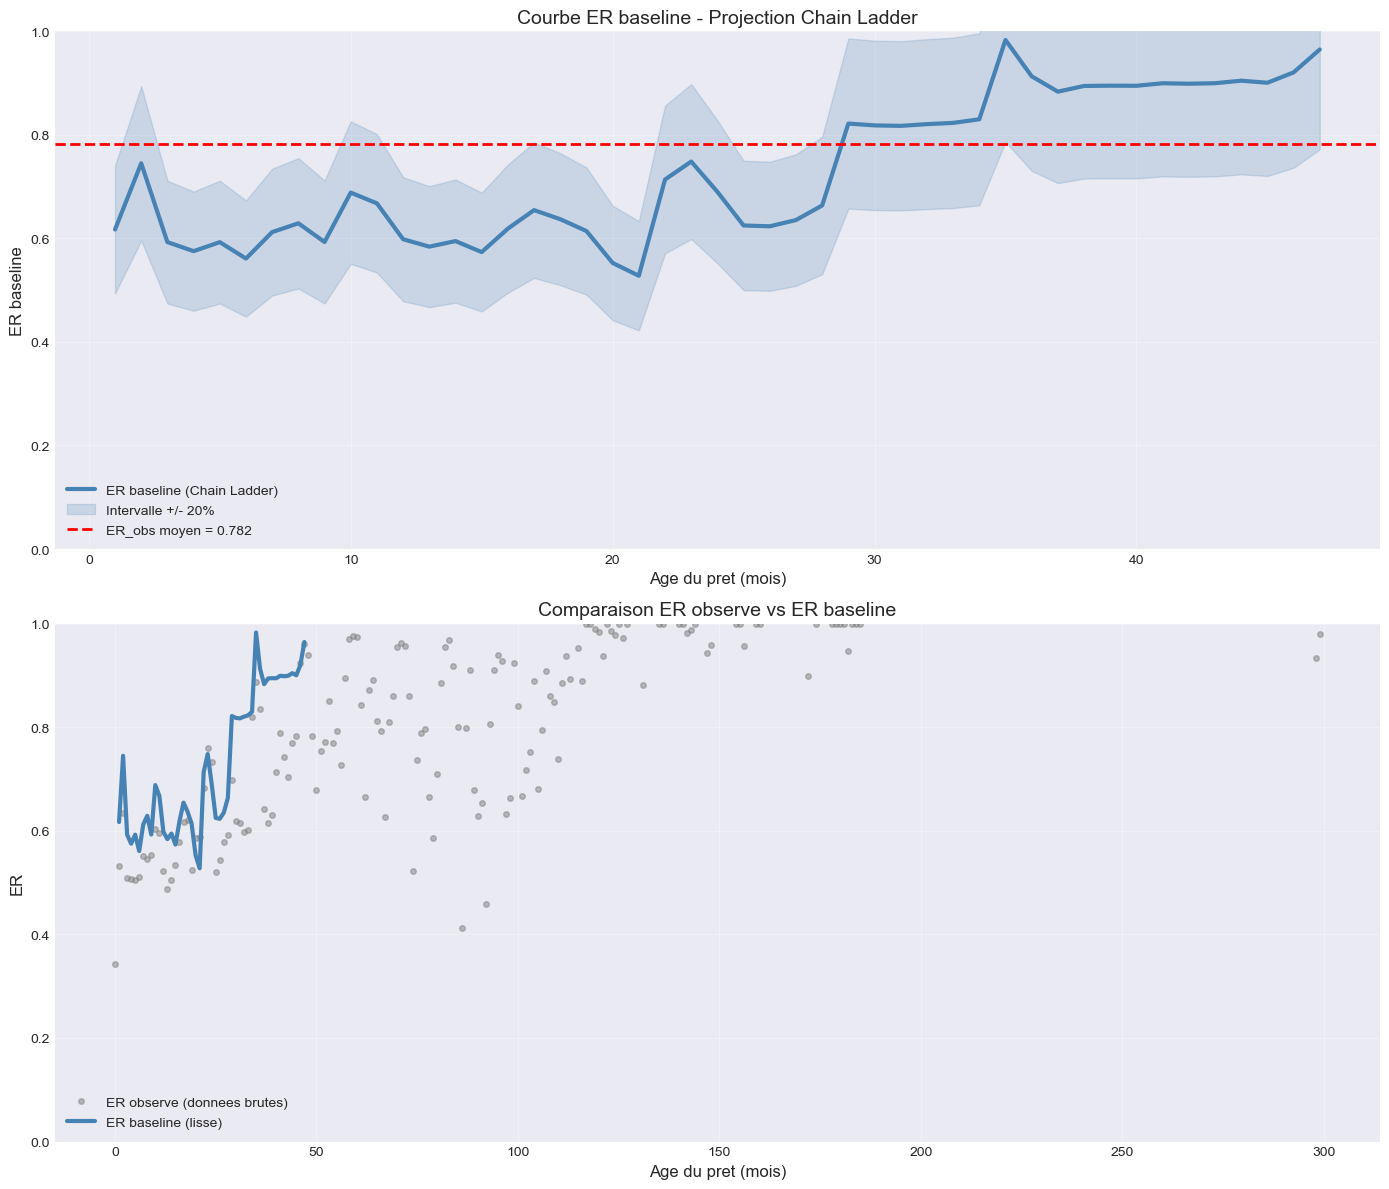

Interpretation :
  - La baseline capture la tendance moyenne de l'ER selon l'age
  - Elle lisse les variations individuelles et le bruit des donnees
  - L'ecart entre baseline et observe reflete la variabilite individuelle


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Graphique 1 : Courbe baseline
ages_plot = er_baseline_by_age_normalized.index[:48]
values_plot = er_baseline_by_age_normalized.values[:48]

axes[0].plot(ages_plot, values_plot, linewidth=3, color='steelblue', label='ER baseline (Chain Ladder)')
axes[0].fill_between(ages_plot, values_plot * 0.8, values_plot * 1.2,
                      alpha=0.2, color='steelblue', label='Intervalle +/- 20%')
axes[0].axhline(y=er_obs_mean, color='red', linestyle='--', linewidth=2, 
                label=f'ER_obs moyen = {er_obs_mean:.3f}')
axes[0].set_xlabel('Age du pret (mois)', fontsize=12)
axes[0].set_ylabel('ER baseline', fontsize=12)
axes[0].set_title('Courbe ER baseline - Projection Chain Ladder', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Graphique 2 : Comparaison avec ER observe
# Calculer ER observe moyen par age
er_obs_by_age = df.groupby('AGE_PRET')['ER_obs'].agg(['mean', 'std', 'count']).reset_index()
er_obs_by_age = er_obs_by_age[er_obs_by_age['count'] >= 10]

axes[1].plot(er_obs_by_age['AGE_PRET'], er_obs_by_age['mean'], 
             'o', markersize=4, alpha=0.5, color='gray', label='ER observe (donnees brutes)')
axes[1].plot(ages_plot, values_plot, linewidth=3, color='steelblue', label='ER baseline (lisse)')
axes[1].set_xlabel('Age du pret (mois)', fontsize=12)
axes[1].set_ylabel('ER', fontsize=12)
axes[1].set_title('Comparaison ER observe vs ER baseline', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Interpretation :")
print("  - La baseline capture la tendance moyenne de l'ER selon l'age")
print("  - Elle lisse les variations individuelles et le bruit des donnees")
print("  - L'ecart entre baseline et observe reflete la variabilite individuelle")

## Etape 7 : Application aux donnees completes

On map la baseline calculee sur l'ensemble du dataset.

In [12]:
# Mapper la baseline sur le dataframe complet
df['ER_baseline_CL'] = df['AGE_PRET'].map(er_baseline_by_age_normalized)

# Remplir valeurs manquantes
df['ER_baseline_CL'] = df['ER_baseline_CL'].fillna(method='ffill').fillna(method='bfill')

# Si encore des NaN, utiliser la moyenne
if df['ER_baseline_CL'].isna().any():
    df['ER_baseline_CL'] = df['ER_baseline_CL'].fillna(er_baseline_by_age_normalized.mean())

print(f"Baseline appliquee a {len(df)} contrats")
print(f"Valeurs manquantes : {df['ER_baseline_CL'].isna().sum()}")
print(f"\nStatistiques ER_baseline_CL :")
print(df['ER_baseline_CL'].describe())

Baseline appliquee a 26519 contrats
Valeurs manquantes : 0

Statistiques ER_baseline_CL :
count    26519.000000
mean         0.803710
std          0.161266
min          0.527821
25%          0.624949
50%          0.830084
75%          0.967072
max          0.983265
Name: ER_baseline_CL, dtype: float64


## Etape 8 : Evaluation de la performance

On evalue la capacite predictive de la baseline seule en calculant les metriques standards :
- **R2** : proportion de variance expliquee (0 = mauvais, 1 = parfait)
- **RMSE** : erreur quadratique moyenne
- **MAE** : erreur absolue moyenne

In [13]:
# Split train/test
X_dummy = df[['AGE_PRET']]
y = df['ER_obs']
X_train, X_test, y_train, y_test = train_test_split(X_dummy, y, test_size=0.2, random_state=42)

# Predictions = baseline
y_pred_cl = df.loc[y_test.index, 'ER_baseline_CL'].values

# Metriques
r2_cl = r2_score(y_test, y_pred_cl)
rmse_cl = np.sqrt(mean_squared_error(y_test, y_pred_cl))
mae_cl = mean_absolute_error(y_test, y_pred_cl)

print("PERFORMANCE CHAIN LADDER")
print("=" * 60)
print(f"R2 (variance expliquee)     : {r2_cl:.4f}")
print(f"RMSE (erreur quadratique)   : {rmse_cl:.4f}")
print(f"MAE (erreur absolue)        : {mae_cl:.4f}")
print()
print("Interpretation :")
if r2_cl < 0.10:
    print(f"  - R2 = {r2_cl:.3f} : La baseline seule explique tres peu de variance")
    print("  - Les caracteristiques individuelles dominent")
elif r2_cl < 0.30:
    print(f"  - R2 = {r2_cl:.3f} : La baseline capte une partie de la variance")
    print("  - Mais insuffisant pour predictions individuelles precises")
else:
    print(f"  - R2 = {r2_cl:.3f} : La baseline est informative")
    print("  - L'age du pret est un predicteur important de l'ER")

PERFORMANCE CHAIN LADDER
R2 (variance expliquee)     : 0.0881
RMSE (erreur quadratique)   : 0.3478
MAE (erreur absolue)        : 0.2500

Interpretation :
  - R2 = 0.088 : La baseline seule explique tres peu de variance
  - Les caracteristiques individuelles dominent


### Graphique predictions vs realite

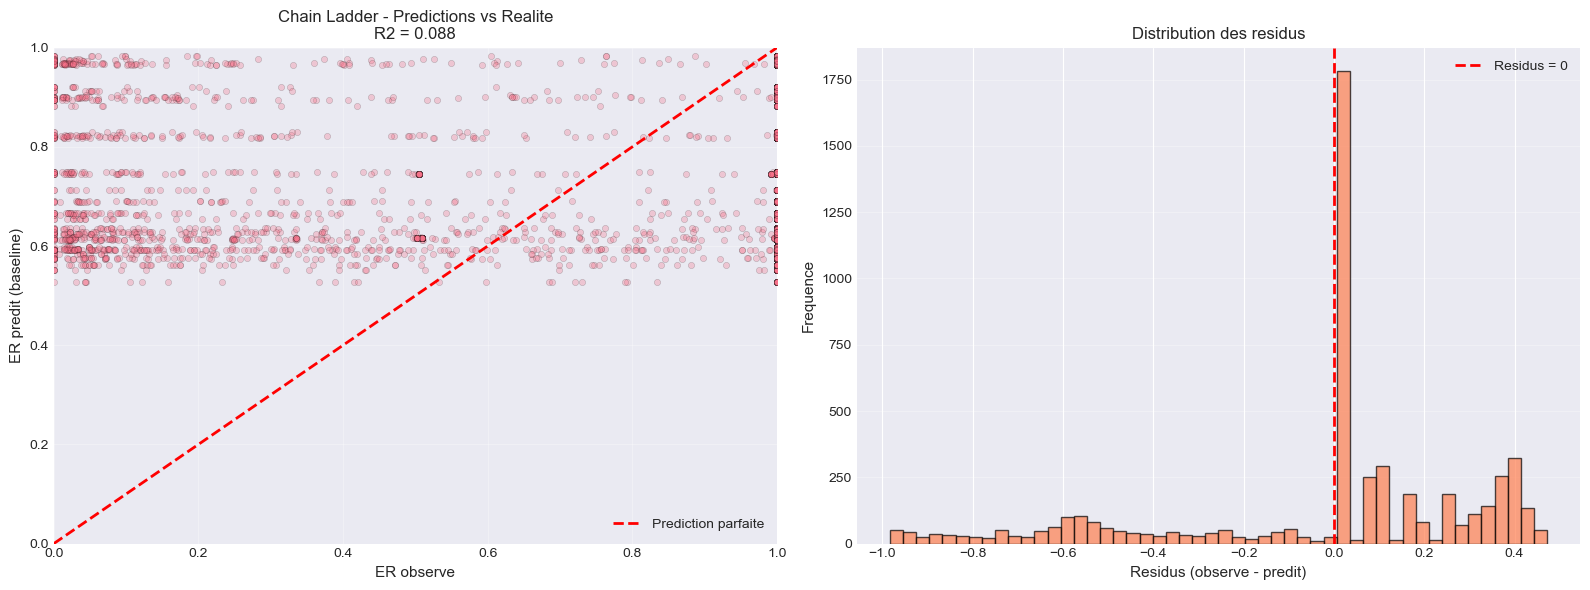

Moyenne des residus : -0.0210 (devrait etre proche de 0)
Ecart-type residus  : 0.3472


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred_cl, alpha=0.3, s=20, edgecolors='black', linewidth=0.3)
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Prediction parfaite')
axes[0].set_xlabel('ER observe', fontsize=11)
axes[0].set_ylabel('ER predit (baseline)', fontsize=11)
axes[0].set_title(f'Chain Ladder - Predictions vs Realite\nR2 = {r2_cl:.3f}', fontsize=12)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution des residus
residuals = y_test - y_pred_cl
axes[1].hist(residuals, bins=50, edgecolor='black', color='coral', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Residus = 0')
axes[1].set_xlabel('Residus (observe - predit)', fontsize=11)
axes[1].set_ylabel('Frequence', fontsize=11)
axes[1].set_title('Distribution des residus', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Moyenne des residus : {residuals.mean():.4f} (devrait etre proche de 0)")
print(f"Ecart-type residus  : {residuals.std():.4f}")

## Synthese et limites de l'approche Chain Ladder

### Points forts

1. **Simplicite conceptuelle** : methode intuitive basee sur les patterns historiques
2. **Robustesse actuarielle** : approche eprouvee en provisionnement depuis des decennies
3. **Pas de sur-ajustement** : peu de parametres, pas de risque d'overfitting
4. **Interpretabilite** : facile a expliquer aux actuaires et decideurs
5. **Capture l'effet age** : met en evidence l'evolution naturelle de l'ER avec la maturite

### Limites

1. **Variance individuelle ignoree** : 
   - La baseline est une moyenne, elle ne capte pas les specificites de chaque contrat
   - Caracteristiques client (revenus, age, taux) non prises en compte
   
2. **Hypothese d'homogeneite** :
   - Suppose que toutes les cohortes evoluent de maniere similaire
   - Ignore les changements structurels du marche

3. **Performance predictive faible** :
   - R2 faible (typiquement < 0.15)
   - Insuffisant pour predictions individuelles precises

4. **Sensibilite aux donnees** :
   - Necessite des cohortes completes et robustes
   - Problematique si peu de donnees historiques

5. **Pas de prevision causale** :
   - Ne modelise pas les drivers du remboursement anticipe
   - Approche purement descriptive

### Recommandations d'usage

**Utiliser Chain Ladder pour** :
- Analyse exploratoire et comprehension des patterns temporels
- Benchmarking et validation d'autres modeles
- Reporting actuariel et communication interne
- Projections aggregees au niveau portefeuille

**Ne PAS utiliser Chain Ladder seul pour** :
- Predictions individuelles precises
- Provisionnement IFRS9 (necessite caracteristiques individuelles)
- Pricing client-specifique
- Applications necessitant R2 > 0.50

### Suite

Les notebooks suivants presenteront des approches plus sophistiquees :
- **Notebook 2** : Survival Analysis (Cox, Kaplan-Meier)
- **Notebook 3** : Machine Learning (Random Forest)
- **Notebook 4** : Modele Hybride (Cox + ML)

Ces methodes permettront d'integrer les caracteristiques individuelles et d'ameliorer significativement la performance predictive.

## Sauvegarde des resultats

In [ ]:
# # Sauvegarder la baseline
# er_baseline_by_age_normalized.to_csv('chain_ladder_baseline.csv', header=['ER_baseline'])

# # Sauvegarder les facteurs
# factors_df = pd.DataFrame({
#     'Age': list(factors_er.keys()),
#     'Facteur': list(factors_er.values())
# })
# factors_df.to_csv('chain_ladder_factors.csv', index=False)

# # Sauvegarder les metriques
# results_cl = pd.DataFrame({
#     'Approche': ['Chain Ladder'],
#     'R2': [r2_cl],
#     'RMSE': [rmse_cl],
#     'MAE': [mae_cl]
# })
# results_cl.to_csv('chain_ladder_performance.csv', index=False)

# print("Fichiers sauvegardes :")
# print("  - chain_ladder_baseline.csv")
# print("  - chain_ladder_factors.csv")
# print("  - chain_ladder_performance.csv")

Fichiers sauvegardes :
  - chain_ladder_baseline.csv
  - chain_ladder_factors.csv
  - chain_ladder_performance.csv
